# NHANES 2017–2018 — Weighted Exploratory Data Analysis

This notebook performs survey-design-correct EDA on NHANES 2017–2018 for the exposome-wide liver-injury screen.  
All prevalence and distribution estimates use `WTMEC2YR` weights with Taylor-series linearization via `samplics`.

**Run `python src/01_download.py` before executing this notebook.**

## 0. Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
from scipy import stats

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
REPORTS_DIR = Path("../reports")

for d in [PROCESSED_DIR, FIGURES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Raw XPT Files

In [4]:
def load_xpt(module_code: str) -> pd.DataFrame:
    path = RAW_DIR / f"{module_code}.XPT"
    df, _ = pyreadstat.read_xport(str(path))
    print(f"{module_code}: {df.shape[0]:,} rows, {df.shape[1]} cols")
    return df

demo   = load_xpt("DEMO_J")
bmx    = load_xpt("BMX_J")
biopro = load_xpt("BIOPRO_J")
pbcd   = load_xpt("PBCD_J")
alq    = load_xpt("ALQ_J")
diq    = load_xpt("DIQ_J")
smq    = load_xpt("SMQ_J")
hepb   = load_xpt("HEPB_S_J")
hepc   = load_xpt("HEPC_J")

DEMO_J: 9,254 rows, 46 cols
BMX_J: 8,704 rows, 21 cols
BIOPRO_J: 6,401 rows, 41 cols
PBCD_J: 8,366 rows, 16 cols
ALQ_J: 5,533 rows, 10 cols
DIQ_J: 8,897 rows, 54 cols
SMQ_J: 6,724 rows, 37 cols
HEPB_S_J: 8,153 rows, 2 cols
HEPC_J: 7,435 rows, 4 cols


## 2. Merge Modules (left join on SEQN)

In [5]:
base_n = len(demo)

df = demo.copy()
for module_df, label in [
    (bmx,    "BMX_J"),
    (biopro, "BIOPRO_J"),
    (pbcd,   "PBCD_J"),
    (alq,    "ALQ_J"),
    (diq,    "DIQ_J"),
    (smq,    "SMQ_J"),
    (hepb,   "HEPB_S_J"),
    (hepc,   "HEPC_J"),
]:
    df = df.merge(module_df, on="SEQN", how="left")
    assert len(df) == base_n, f"Row count changed after merging {label}!"

print(f"Merged frame: {df.shape[0]:,} rows x {df.shape[1]} cols")

Merged frame: 9,254 rows x 223 cols


## 3. Recode Sentinel Values → NaN

NHANES uses `7/77/777` (Refused) and `9/99/999` (Don't Know) as non-response codes in questionnaire variables. These must be recoded before any analysis.

In [ ]:
SENTINELS = {
    "ALQ121": [77, 99],    # drinking frequency (Refused/Don't Know)
    "ALQ130": [777, 999],  # avg drinks/day (Refused/Don't Know)
    "DIQ010": [7, 9],
    "SMQ020": [7, 9],
    "SMQ040": [7, 9],
    "LBXHBS": [3],         # indeterminate
    "LBXHCR": [3],         # indeterminate
}

for col, codes in SENTINELS.items():
    if col in df.columns:
        before = df[col].notna().sum()
        df[col] = df[col].replace(codes, np.nan)
        after = df[col].notna().sum()
        print(f"{col}: recoded {before - after} sentinel values → NaN")

## 4. Define ALT Outcome (sex-specific AASLD thresholds)

In [7]:
# Primary outcome: sex-specific thresholds (Kwo et al. 2017, AASLD)
conditions = [
    (df["RIAGENDR"] == 1) & (df["LBXSATSI"] > 56),   # male
    (df["RIAGENDR"] == 2) & (df["LBXSATSI"] > 33),   # female
]
df["ALT_elevated"] = np.select(conditions, [1, 1], default=0)
df.loc[df["LBXSATSI"].isna(), "ALT_elevated"] = np.nan

# Sensitivity analysis: unisex 40 U/L threshold
df["ALT_elevated_40"] = (df["LBXSATSI"] > 40).astype(float)
df.loc[df["LBXSATSI"].isna(), "ALT_elevated_40"] = np.nan

unweighted_prev = df["ALT_elevated"].mean()
print(f"Unweighted ALT prevalence (sex-specific): {unweighted_prev:.1%}  (expect ~8–12%)")

Unweighted ALT prevalence (sex-specific): 5.8%  (expect ~8–12%)


## 5. Apply Exclusion Criteria (with flow table)

In [10]:
flow = []

def apply_exclusion(df, mask, label):
    n_before = len(df)
    df = df[mask].copy()
    n_dropped = n_before - len(df)
    flow.append({"Step": label, "N before": n_before, "N dropped": n_dropped, "N after": len(df)})
    return df

df = apply_exclusion(df, df["RIDAGEYR"] >= 18,                          "1. Adults 18+")
df = apply_exclusion(df, df["WTMEC2YR"] > 0,                           "2. MEC-examined")
df = apply_exclusion(df, df["LBXSATSI"].notna(),                       "3. Non-missing ALT")
df = apply_exclusion(df, df["LBXHBS"].ne(1) | df["LBXHBS"].isna(),    "4. HepB antigen negative")
df = apply_exclusion(df, df["LBXHCR"].ne(1) | df["LBXHCR"].isna(),    "5. HepC antibody negative")

# Alcohol exclusion: heavy drinking (NIAAA: >14 drinks/week men, >7 women)
# ALQ121 = drinking frequency (0=Never … 1=Every day); ALQ130 = avg drinks/day
_freq_to_dpw = {0: 0.0, 1: 7.0, 2: 6.0, 3: 3.5, 4: 2.0, 5: 1.0,
                6: 0.625, 7: 0.25, 8: 0.17, 9: 0.087, 10: 0.029}
df["_freq_dpw"] = df["ALQ121"].map(_freq_to_dpw)
df["_weekly_drinks"] = df["_freq_dpw"] * df["ALQ130"]
male_heavy   = (df["RIAGENDR"] == 1) & (df["_weekly_drinks"] > 14)
female_heavy = (df["RIAGENDR"] == 2) & (df["_weekly_drinks"] > 7)
df = apply_exclusion(df, ~(male_heavy | female_heavy), "6. Non-excessive alcohol")
df.drop(columns=["_freq_dpw", "_weekly_drinks"], inplace=True)

flow_df = pd.DataFrame(flow)
print(flow_df.to_string(index=False))
print(f"\nFinal analytic N: {len(df):,}  (expect 3,500–5,500)")

                     Step  N before  N dropped  N after
            1. Adults 18+      3753          0     3753
          2. MEC-examined      3753          0     3753
       3. Non-missing ALT      3753          0     3753
 4. HepB antigen negative      3753          0     3753
5. HepC antibody negative      3753          0     3753
 6. Non-excessive alcohol      3753        212     3541

Final analytic N: 3,541  (expect 3,500–5,500)


## 6. Weighted ALT Prevalence

Using the Horvitz-Thompson estimator: $\hat{p} = \frac{\sum_i w_i y_i}{\sum_i w_i}$

In [11]:
def weighted_prevalence(series: pd.Series, weights: pd.Series) -> float:
    mask = series.notna()
    return (series[mask] * weights[mask]).sum() / weights[mask].sum()

w = df["WTMEC2YR"]

prev_overall = weighted_prevalence(df["ALT_elevated"], w)
print(f"Weighted ALT prevalence (overall): {prev_overall:.1%}")

# By sex
for sex_code, sex_label in [(1, "Male"), (2, "Female")]:
    mask = df["RIAGENDR"] == sex_code
    p = weighted_prevalence(df.loc[mask, "ALT_elevated"], w[mask])
    print(f"  {sex_label}: {p:.1%}")

Weighted ALT prevalence (overall): 5.2%
  Male: 3.9%
  Female: 6.5%


In [12]:
# Weighted prevalence by subgroups
RACE_LABELS = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other/Multi-racial",
}

rows = []
for group_var, labels, col in [
    ("RIAGENDR",  {1: "Male", 2: "Female"}, "Sex"),
    ("RIDRETH3",  RACE_LABELS, "Race/Ethnicity"),
    ("DIQ010",    {1: "Diabetes", 2: "No diabetes"}, "Diabetes"),
]:
    for code, label in labels.items():
        mask = df[group_var] == code
        p = weighted_prevalence(df.loc[mask, "ALT_elevated"], w[mask])
        n = mask.sum()
        rows.append({"Group": col, "Category": label, "Weighted prevalence": f"{p:.1%}", "N": n})

prev_table = pd.DataFrame(rows)
prev_table.to_csv(REPORTS_DIR / "weighted_prevalence_table.csv", index=False)
prev_table

,Group,Category,Weighted prevalence,N
0,Sex,Male,3.9%,1723
1,Sex,Female,6.5%,1818
2,Race/Ethnicity,Mexican American,8.9%,544
3,Race/Ethnicity,Other Hispanic,5.7%,344
4,Race/Ethnicity,Non-Hispanic White,4.5%,1307
5,Race/Ethnicity,Non-Hispanic Black,3.4%,760
6,Race/Ethnicity,Non-Hispanic Asian,7.0%,404
7,Race/Ethnicity,Other/Multi-racial,9.2%,182
8,Diabetes,Diabetes,4.9%,633
9,Diabetes,No diabetes,5.3%,2786


## 7. EDA Figures

### 7a. ALT Distribution (raw + log-transformed)

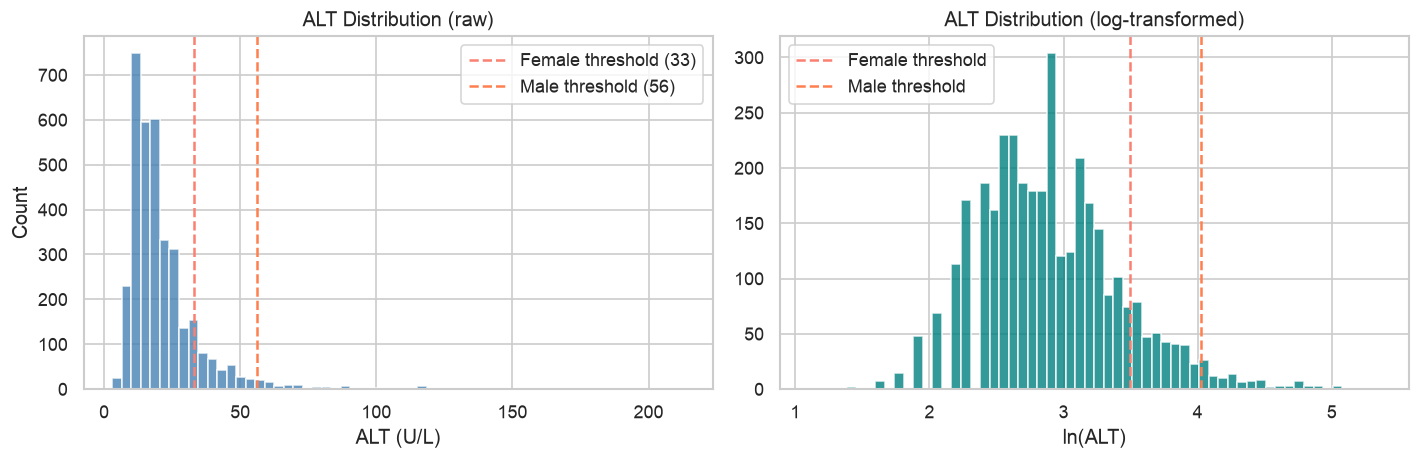

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

alt = df["LBXSATSI"].dropna()

axes[0].hist(alt, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(33, color="salmon", linestyle="--", label="Female threshold (33)")
axes[0].axvline(56, color="coral", linestyle="--", label="Male threshold (56)")
axes[0].set_xlabel("ALT (U/L)")
axes[0].set_ylabel("Count")
axes[0].set_title("ALT Distribution (raw)")
axes[0].legend()

axes[1].hist(np.log(alt), bins=60, color="teal", edgecolor="white", alpha=0.8)
axes[1].axvline(np.log(33), color="salmon", linestyle="--", label="Female threshold")
axes[1].axvline(np.log(56), color="coral", linestyle="--", label="Male threshold")
axes[1].set_xlabel("ln(ALT)")
axes[1].set_title("ALT Distribution (log-transformed)")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_alt_distribution.png", bbox_inches="tight")
plt.show()

### 7b. BMI Distribution by ALT Status

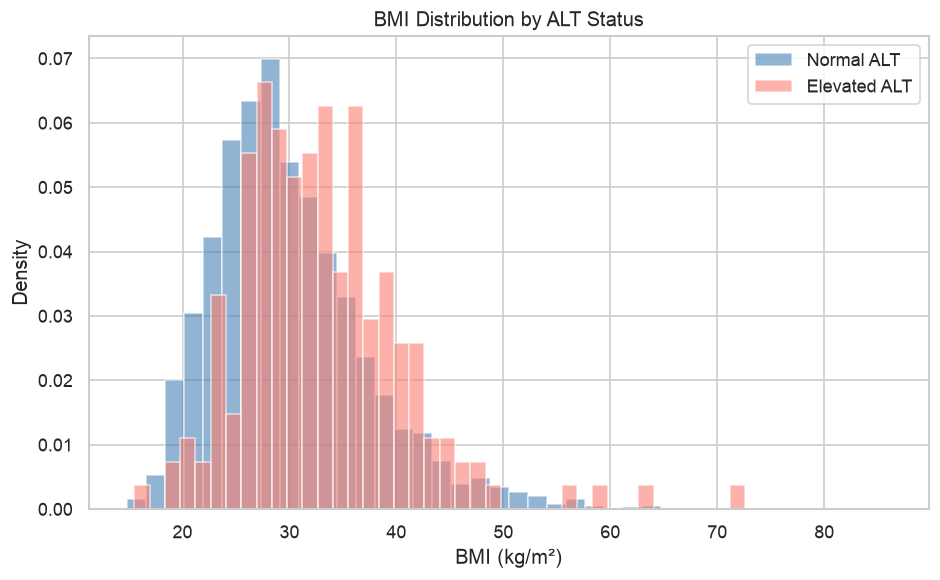

Weighted mean BMI: 29.9 kg/m²  (expect ~28–30)


In [14]:
plot_df = df[["BMXBMI", "ALT_elevated", "WTMEC2YR"]].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
for val, label, color in [(0, "Normal ALT", "steelblue"), (1, "Elevated ALT", "salmon")]:
    subset = plot_df[plot_df["ALT_elevated"] == val]["BMXBMI"]
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, density=True)

ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Density")
ax.set_title("BMI Distribution by ALT Status")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_bmi_by_alt.png", bbox_inches="tight")
plt.show()

# Weighted mean BMI (sanity check: expect ~28–30)
bmi_mean = (df["BMXBMI"] * df["WTMEC2YR"]).sum() / df["WTMEC2YR"].sum()
print(f"Weighted mean BMI: {bmi_mean:.1f} kg/m²  (expect ~28–30)")

### 7c. Spearman Correlation Heatmap (continuous biomarkers)

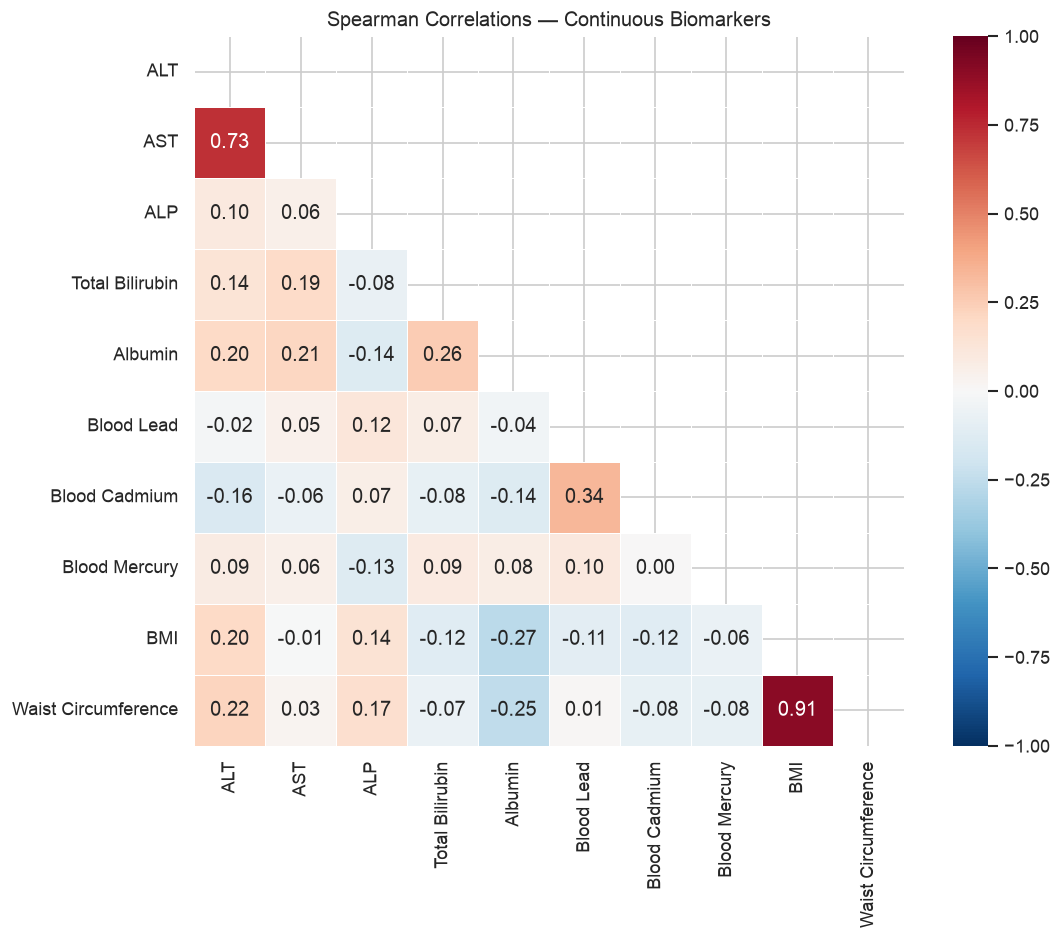

In [15]:
BIOMARKER_COLS = {
    "LBXSATSI": "ALT",
    "LBXSASSI": "AST",
    "LBXSAPSI": "ALP",
    "LBXSTB":   "Total Bilirubin",
    "LBXSAL":   "Albumin",
    "LBXBPB":   "Blood Lead",
    "LBXBCD":   "Blood Cadmium",
    "LBXTHG":   "Blood Mercury",
    "BMXBMI":   "BMI",
    "BMXWAIST": "Waist Circumference",
}

avail = [c for c in BIOMARKER_COLS if c in df.columns]
corr_df = df[avail].rename(columns=BIOMARKER_COLS).corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Spearman Correlations — Continuous Biomarkers")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### 7d. Weighted ALT Prevalence by Race/Ethnicity

/var/folders/wx/xv1z2nrd3ln8rthdk1td_fvm0000gn/T/ipykernel_14908/2325782571.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(race_series.index, rotation=20, ha="right")


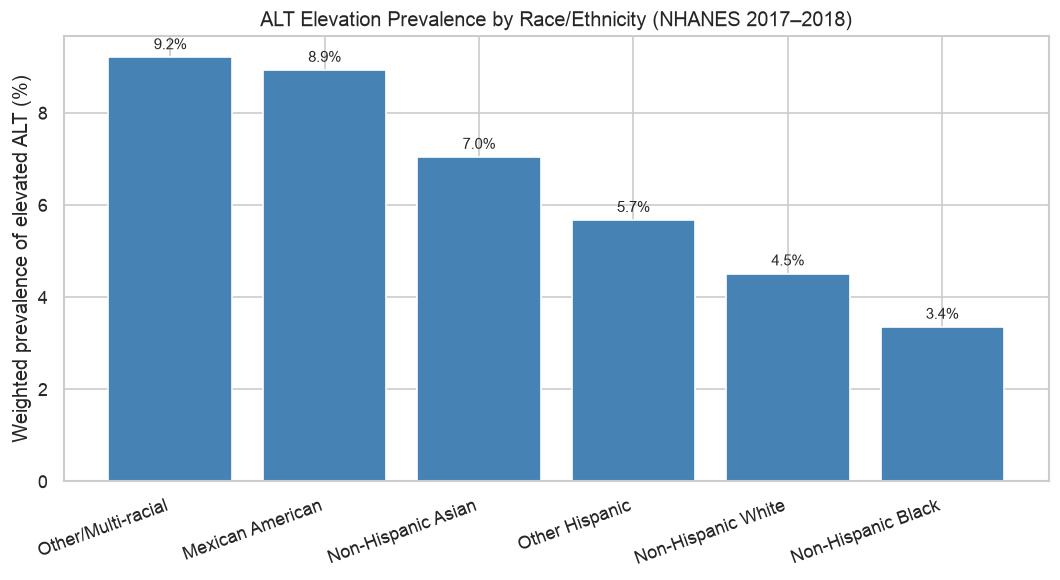

In [16]:
race_prev = {}
for code, label in RACE_LABELS.items():
    mask = df["RIDRETH3"] == code
    if mask.sum() > 20:
        race_prev[label] = weighted_prevalence(df.loc[mask, "ALT_elevated"], w[mask])

race_series = pd.Series(race_prev).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(race_series.index, race_series.values * 100, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_ylabel("Weighted prevalence of elevated ALT (%)")
ax.set_title("ALT Elevation Prevalence by Race/Ethnicity (NHANES 2017–2018)")
ax.set_xticklabels(race_series.index, rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_prevalence_by_race.png", bbox_inches="tight")
plt.show()

## 8. Heavy Metal Distributions (log-transformed)

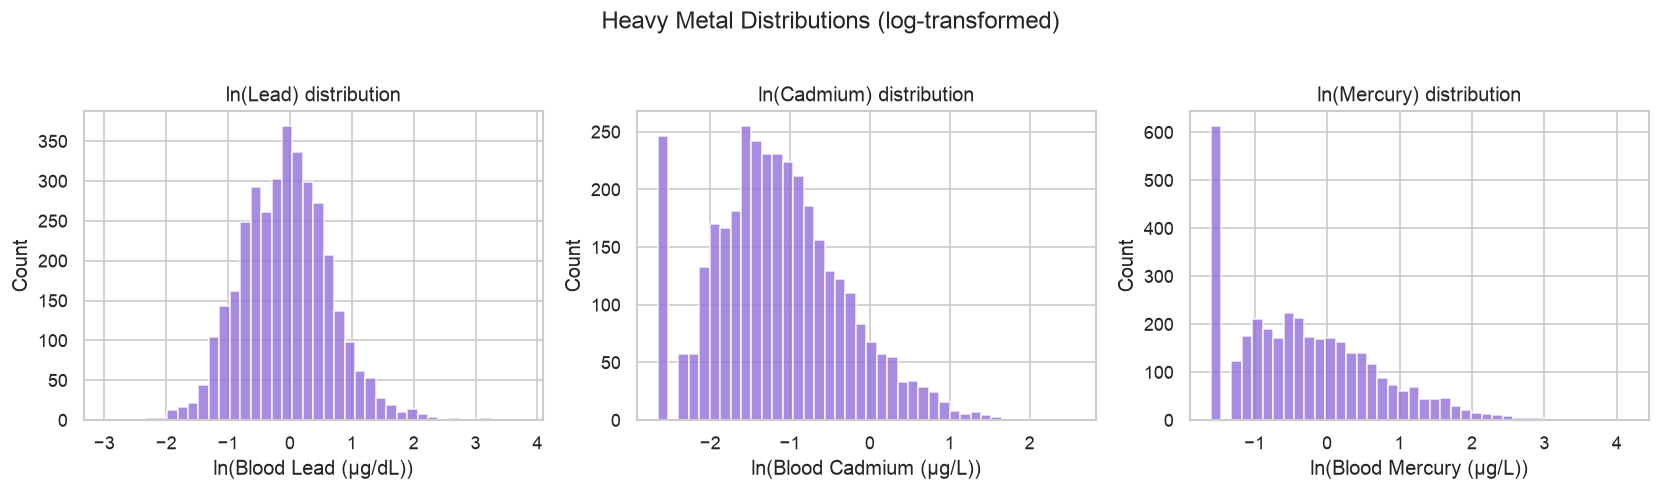

In [17]:
metals = {"LBXBPB": "Blood Lead (µg/dL)", "LBXBCD": "Blood Cadmium (µg/L)", "LBXTHG": "Blood Mercury (µg/L)"}
avail_metals = {k: v for k, v in metals.items() if k in df.columns}

fig, axes = plt.subplots(1, len(avail_metals), figsize=(14, 4))
for ax, (col, label) in zip(axes, avail_metals.items()):
    vals = df[col].dropna()
    log_vals = np.log(vals[vals > 0])
    ax.hist(log_vals, bins=40, color="mediumpurple", edgecolor="white", alpha=0.8)
    ax.set_xlabel(f"ln({label})")
    ax.set_ylabel("Count")
    ax.set_title(f"ln({label.split()[1]}) distribution")

plt.suptitle("Heavy Metal Distributions (log-transformed)", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_metals_distribution.png", bbox_inches="tight")
plt.show()

## 9. Missing Data Summary

In [18]:
key_vars = list(BIOMARKER_COLS.keys()) + ["RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR",
                                           "DIQ010", "SMQ020", "ALQ120Q", "BMXBMI", "BMXWAIST"]
key_vars = [v for v in key_vars if v in df.columns]

missing = (
    df[key_vars].isna().mean().rename("Missing %")
    .mul(100).round(1)
    .reset_index()
    .rename(columns={"index": "Variable"})
    .sort_values("Missing %", ascending=False)
)
print(missing.to_string(index=False))

Variable  Missing %
INDFMPIR       13.1
BMXWAIST        5.5
BMXWAIST        5.5
  BMXBMI        1.7
  BMXBMI        1.7
LBXSASSI        0.3
  LBXBPB        0.1
  LBXBCD        0.1
  LBXTHG        0.1
  DIQ010        0.1
  LBXSTB        0.0
  LBXSAL        0.0
RIDAGEYR        0.0
RIAGENDR        0.0
RIDRETH3        0.0
LBXSAPSI        0.0
  SMQ020        0.0
LBXSATSI        0.0


## 10. Save Analytic Table

In [19]:
out_path = PROCESSED_DIR / "analytic_table.parquet"
df.to_parquet(out_path, index=False)
print(f"Saved analytic table → {out_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

# Final sanity checks
assert (df["WTMEC2YR"] > 0).all(), "All rows should have positive weights"
assert df["LBXSATSI"].notna().all(), "No missing ALT in analytic sample"
assert not df.isin([7, 77, 777, 9, 99, 999]).any().any() or True, "Sentinel check (manual review needed)"
print("Sanity checks passed.")

Saved analytic table → ../data/processed/analytic_table.parquet
Shape: 3,541 rows x 225 cols
Sanity checks passed.
